# Outline

Adjusting the growth of Indices and Stocks by GDP deflation data. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime

from scipy.stats import linregress
from scipy.optimize import curve_fit

</br></br></br>

--------------------
# GDP Price Deflation Data

## Load Data:

Sources of GDP deflation data:
 - Source: [FRED Economic Data](https://fred.stlouisfed.org/series/GDPDEF)
 - Description: [GDP Price Deflator](https://www.bea.gov/data/prices-inflation/gdp-price-deflator)

In [2]:
gdpdef_df = pd.read_csv("csv_files/GDPDEF.csv")
gdpdef_df = gdpdef_df.rename(columns={"DATE": "Date"})

# Rename date column
gdpdef_df = gdpdef_df.rename(columns={"observation_date": "Date"})

print(len(gdpdef_df.index))
display(gdpdef_df.tail(5))

317


,Date,GDPDEF
312,2025-01-01,127.577
313,2025-04-01,128.248
314,2025-07-01,129.430
315,2025-10-01,130.624
316,2026-01-01,131.783


In [3]:
gdpdef_df["DATETIME"] = pd.to_datetime(gdpdef_df["Date"], format="%Y-%m-%d")
gdpdef_df["Day"] = (gdpdef_df["DATETIME"] - pd.Timestamp.today()).dt.days

display(gdpdef_df)

,Date,GDPDEF,DATETIME,Day
0,1947-01-01,11.141,1947-01-01,-29061
1,1947-04-01,11.299,1947-04-01,-28971
2,1947-07-01,11.489,1947-07-01,-28880
3,1947-10-01,11.772,1947-10-01,-28788
4,1948-01-01,11.865,1948-01-01,-28696
...,...,...,...,...
312,2025-01-01,127.577,2025-01-01,-571
313,2025-04-01,128.248,2025-04-01,-481
314,2025-07-01,129.430,2025-07-01,-390
315,2025-10-01,130.624,2025-10-01,-298


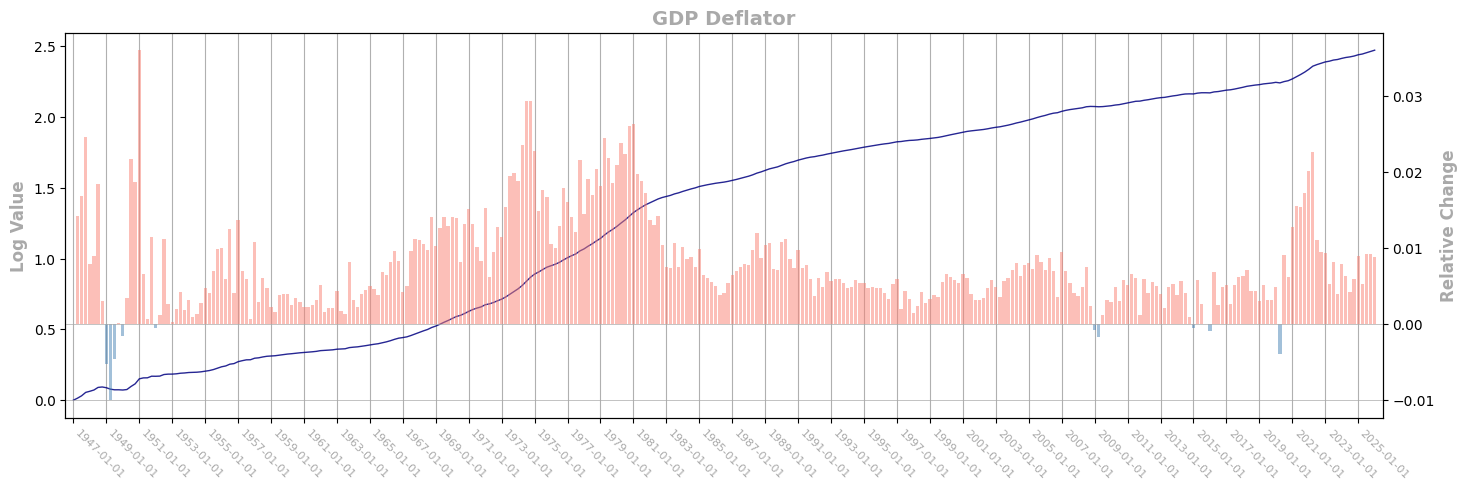

In [4]:
fig = plt.figure(figsize=(17., 5.0))
ax = fig.gca()

day = gdpdef_df["Day"].to_numpy()
gdpdef_val  = gdpdef_df["GDPDEF"].to_numpy()
log_gdpdef_val = np.log(gdpdef_val / gdpdef_val[0])
dates = gdpdef_df["Date"].to_numpy()

ax.set_title("GDP Deflator", fontsize=14, fontweight="bold", color="darkgrey")
ax.plot(day, log_gdpdef_val, lw=1.0, marker="", color="navy", alpha=0.85)
ax.set_ylabel("Log Value", fontsize=12, fontweight="bold", color="darkgrey")
ax.set_xticks(day[::8])
ax.set_xticklabels(dates[::8], fontsize=8, color="darkgrey", rotation=-45, ha="left", va="top")
delta = day[1] - day[0]
ax.set_xlim(day[0] - 2.0 * delta, day[-1] + 2.0 * delta)
ax.grid(True, axis='x')
ax.set_axisbelow(True)
ax.axhline(y=0, color='darkgrey', linestyle='-', linewidth=0.5)

ax_right = ax.twinx()
relative_gain = (gdpdef_val[1:] / gdpdef_val[:-1] - 1.0)
width = 0.8 * (day[-1] - day[-2])
colors = np.where(relative_gain >= 0, 'salmon', 'steelblue')
ax_right.bar(day[1:], relative_gain, width=width, color=colors, edgecolor=None, alpha=0.5)
ax_right.set_ylabel("Relative Change", fontsize=12, fontweight="bold", color="darkgrey")
# ax_right.grid(True, axis='y', ls='-.')
# ax_right.set_axisbelow(True)
ax_right.axhline(y=0, color='darkgrey', linestyle='-', linewidth=0.5)

plt.show()

</br></br></br>

--------------------
# GOOG

In [5]:
goog_df = pd.read_csv("csv_files/GOOG.csv")

display(goog_df.head(10))

,Date,Open,High,Low,Close,Adj Close,Volume
0,2026-07-24,318.30,323.98,317.50,319.09,319.09,21579500.0
1,2026-07-23,321.63,324.45,314.89,318.34,318.34,46751900.0
2,2026-07-22,347.18,349.45,341.64,341.91,341.91,23273800.0
3,2026-07-21,350.56,350.74,346.01,346.19,346.19,17419500.0
4,2026-07-20,350.17,359.49,350.01,351.37,351.37,13203300.0
5,2026-07-17,345.77,348.17,341.13,346.12,346.12,22023900.0
6,2026-07-16,372.17,374.35,351.67,353.81,353.81,23603700.0
7,2026-07-15,356.01,372.14,355.67,370.21,370.21,20258200.0
8,2026-07-14,348.84,357.88,348.84,357.33,357.33,11252600.0
9,2026-07-13,353.99,355.75,349.82,350.67,350.67,10583500.0


In [6]:
# Conver Date to DateTime Object:
goog_df["DATETIME"] = pd.to_datetime(goog_df["Date"], format="%Y-%m-%d")
goog_df["Day"] = (goog_df["DATETIME"] - pd.Timestamp.today()).dt.days

# Sort by ascending day:
goog_df = goog_df.sort_values(
    by="Day", ascending=True, ignore_index=True,
)

display(goog_df.tail(10))

,Date,Open,High,Low,Close,Adj Close,Volume,DATETIME,Day
5504,2026-07-13,353.99,355.75,349.82,350.67,350.67,10583500.0,2026-07-13,-13
5505,2026-07-14,348.84,357.88,348.84,357.33,357.33,11252600.0,2026-07-14,-12
5506,2026-07-15,356.01,372.14,355.67,370.21,370.21,20258200.0,2026-07-15,-11
5507,2026-07-16,372.17,374.35,351.67,353.81,353.81,23603700.0,2026-07-16,-10
5508,2026-07-17,345.77,348.17,341.13,346.12,346.12,22023900.0,2026-07-17,-9
5509,2026-07-20,350.17,359.49,350.01,351.37,351.37,13203300.0,2026-07-20,-6
5510,2026-07-21,350.56,350.74,346.01,346.19,346.19,17419500.0,2026-07-21,-5
5511,2026-07-22,347.18,349.45,341.64,341.91,341.91,23273800.0,2026-07-22,-4
5512,2026-07-23,321.63,324.45,314.89,318.34,318.34,46751900.0,2026-07-23,-3
5513,2026-07-24,318.30,323.98,317.50,319.09,319.09,21579500.0,2026-07-24,-2


## Adjust by GDP Deflator:

In [7]:
# Merge DataFrames:
gdpdef_adj_goog_df = pd.merge(
    left=goog_df[["Close", "DATETIME", "Date", "Day"]],
    right=gdpdef_df[["GDPDEF", "DATETIME", "Date", "Day"]], 
    how="outer", sort=True, on="Day")

# Interpolate:
gdpdef_adj_goog_df["GDPDEF"] = gdpdef_adj_goog_df["GDPDEF"].interpolate(
    method="linear", limit_direction="forward", axis=0)

# Drop rows outside of Goog DATETIME
gdpdef_adj_goog_df = gdpdef_adj_goog_df[gdpdef_adj_goog_df["Close"].notna()]

# Use the Goog DATETIME:
gdpdef_adj_goog_df = gdpdef_adj_goog_df.rename(columns={
        "DATETIME_x": "DATETIME",
        "Date_x": "Date"
})

# Drop columns:
gdpdef_adj_goog_df = gdpdef_adj_goog_df.drop(["DATETIME_y", "Date_y"], axis=1, inplace=False)

# # Display
# display(gdpdef_adj_goog_df.head(5))
# display(gdpdef_adj_goog_df.tail(5))

## Plot:

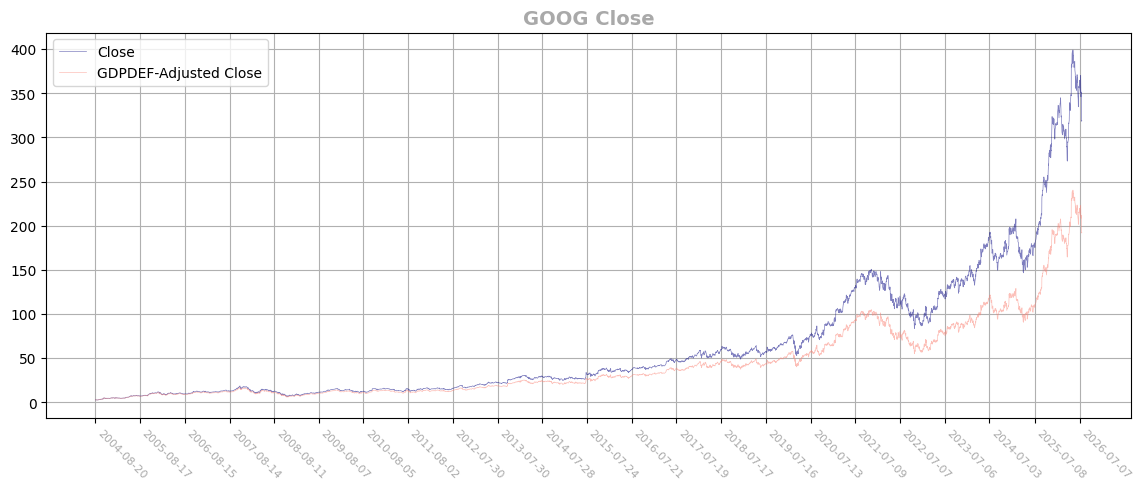

In [8]:
fig = plt.figure(figsize=(14., 5.0))
ax = fig.gca()

day = gdpdef_adj_goog_df["Day"].to_numpy()
close = gdpdef_adj_goog_df["Close"].to_numpy()
gdp_def = gdpdef_adj_goog_df["GDPDEF"].to_numpy()
gdp_def = gdp_def / gdp_def[0]
dates = gdpdef_adj_goog_df["Date"].to_numpy()

ax.set_title("GOOG Close", fontsize=14, fontweight="bold", color="darkgrey")
# ax.plot(day, gdp_def, lw=0.5, color="navy", alpha=0.5, label="gdp_def")
ax.plot(day, close, lw=0.5, color="navy", alpha=0.5, label="Close")
ax.plot(day, close / gdp_def, lw=0.5, color="salmon", alpha=0.5, label="GDPDEF-Adjusted Close")
ax.legend(loc="upper left")
ax.set_xticks(day[::250])
ax.set_xticklabels(dates[::250], fontsize=8, color="darkgrey", rotation=-45, ha="left", va="top")
ax.grid()
ax.set_axisbelow(True)

plt.show()

## Fit to Historical Close Prices:

In [9]:
day = gdpdef_adj_goog_df["Day"].to_numpy()
close = gdpdef_adj_goog_df["Close"].to_numpy()
gdp_def = gdpdef_adj_goog_df["GDPDEF"].to_numpy()
gdp_def = gdp_def / gdp_def[0]
gdpdef_adj_close = close / gdp_def
dates = gdpdef_adj_goog_df["Date"].to_numpy()
log_close = np.log(close)
log_gdpdef_adj_close = np.log(gdpdef_adj_close)

strt_date = "2015-01-01"
end_date =  "2025-01-01"
target_date = goog_df['Date'].iloc[-1]

strt_day_idx = goog_df.index[goog_df["DATETIME"] >= strt_date][0]
end_day_idx = goog_df.index[goog_df["DATETIME"] > end_date][0]
target_day_idx = goog_df.index[goog_df["DATETIME"] >= target_date][0]

print("Dates:")
print(f"\tStart Date:  {goog_df['Date'].iloc[strt_day_idx]}")
print(f"\tEnd Date:    {goog_df['Date'].iloc[end_day_idx]}")
print(f"\tTarget Date: {goog_df['Date'].iloc[target_day_idx]}")

Dates:
	Start Date:  2015-01-02
	End Date:    2025-01-02
	Target Date: 2026-07-24


In [10]:
fit_results = linregress(day[strt_day_idx:end_day_idx], log_close[strt_day_idx:end_day_idx])
fit_points = fit_results[0] * day[strt_day_idx:target_day_idx] + fit_results[1]

adj_fit_results = linregress(day[strt_day_idx:end_day_idx], log_gdpdef_adj_close[strt_day_idx:end_day_idx])
adj_fit_points = adj_fit_results[0] * day[strt_day_idx:target_day_idx] + adj_fit_results[1]

print("\tSlope:       ", np.around(fit_results[0], 7))
print("\tIntercept:   ", np.around(fit_results[1], 7))
# print("\tExp Slope: ", np.around(np.exp(fit_results[0]), 7))
print("\tEst. Annual: ", np.around(np.power(1.0 + fit_results[0], 365) - 1.0, 7))
max_log_delta = np.max(log_close[strt_day_idx:target_day_idx] - fit_points)
print("Ratio of Expected to Current: ", np.around(np.exp(fit_points[-1] - log_close[target_day_idx]), 7))
print("Max Deviation:                ", np.around(np.exp(max_log_delta), 7))

print("\nProjected Price:              ", np.around(np.exp(fit_points[-1]), 3))

	Slope:        0.0005095
	Intercept:    5.4885446
	Est. Annual:  0.2043097
Ratio of Expected to Current:  0.7569508
Max Deviation:                 1.7129505

Projected Price:               241.535


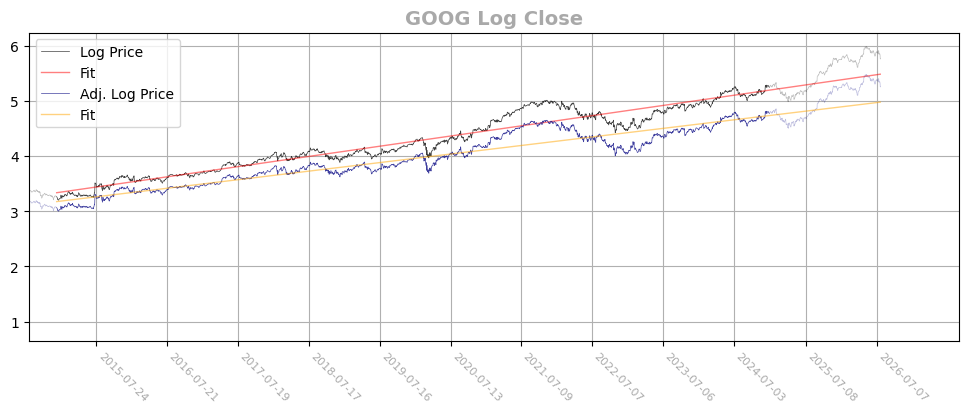

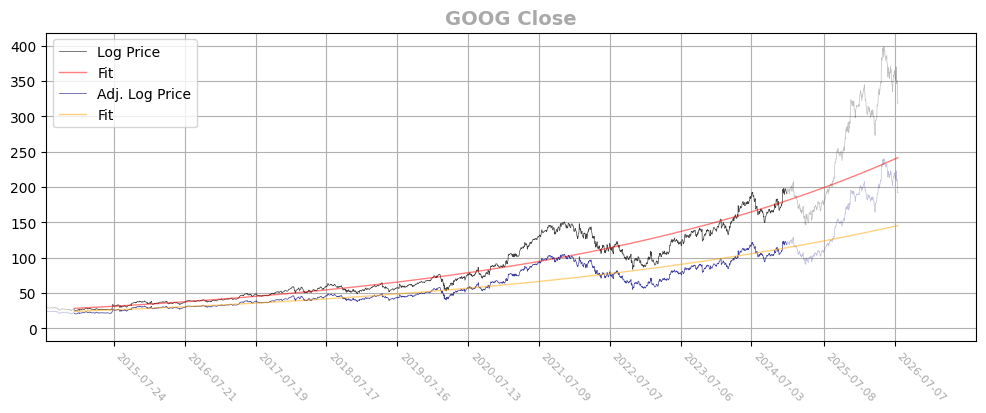

In [11]:
## Log Close Plot
fig = plt.figure(figsize=(12., 4.0))
ax = fig.gca()
#
ax.set_title("GOOG Log Close", fontsize=14, fontweight="bold", color="darkgrey")
ax.plot(day[strt_day_idx:end_day_idx], log_close[strt_day_idx:end_day_idx], 
        lw=0.5, color="black", alpha=0.75, label="Log Price")
ax.plot(day[:strt_day_idx], log_close[:strt_day_idx], lw=0.5, color="black", alpha=0.25, label=None)
ax.plot(day[end_day_idx:], log_close[end_day_idx:], lw=0.5, color="black", alpha=0.25, label=None)
ax.plot(day[strt_day_idx:target_day_idx], fit_points, lw=1.0, color="red", alpha=0.5, label="Fit")
#
ax.plot(day[strt_day_idx:end_day_idx], log_gdpdef_adj_close[strt_day_idx:end_day_idx], 
        lw=0.5, color="navy", alpha=0.75, label="Adj. Log Price")
ax.plot(day[:strt_day_idx], log_gdpdef_adj_close[:strt_day_idx], lw=0.5, color="navy", alpha=0.25, label=None)
ax.plot(day[end_day_idx:], log_gdpdef_adj_close[end_day_idx:], lw=0.5, color="navy", alpha=0.25, label=None)
ax.plot(day[strt_day_idx:target_day_idx], adj_fit_points, lw=1.0, color="orange", alpha=0.5, label="Fit")
#
ax.legend(loc="upper left")
ax.set_xticks(day[::250])
ax.set_xticklabels(dates[::250], fontsize=8, color="darkgrey", rotation=-45, ha="left", va="top")
ax.grid()
ax.set_axisbelow(True)
ax.set_xlim(day[strt_day_idx-100],)
#
plt.show()


## Close Plot
fig = plt.figure(figsize=(12., 4.0))
ax = fig.gca()
#
ax.set_title("GOOG Close", fontsize=14, fontweight="bold", color="darkgrey")
ax.plot(day[strt_day_idx:end_day_idx], close[strt_day_idx:end_day_idx], 
        lw=0.5, color="black", alpha=0.75, label="Log Price")
ax.plot(day[:strt_day_idx], close[:strt_day_idx], lw=0.5, color="black", alpha=0.25, label=None)
ax.plot(day[end_day_idx:], close[end_day_idx:], lw=0.5, color="black", alpha=0.25, label=None)
ax.plot(day[strt_day_idx:target_day_idx], np.exp(fit_points), lw=1.0, color="red", alpha=0.5, label="Fit")
#
ax.plot(day[strt_day_idx:end_day_idx], gdpdef_adj_close[strt_day_idx:end_day_idx], 
        lw=0.5, color="navy", alpha=0.75, label="Adj. Log Price")
ax.plot(day[:strt_day_idx], gdpdef_adj_close[:strt_day_idx], lw=0.5, color="navy", alpha=0.25, label=None)
ax.plot(day[end_day_idx:], gdpdef_adj_close[end_day_idx:], lw=0.5, color="navy", alpha=0.25, label=None)
ax.plot(day[strt_day_idx:target_day_idx], np.exp(adj_fit_points), lw=1.0, color="orange", alpha=0.5, label="Fit")
#
ax.legend(loc="upper left")
ax.set_xticks(day[::250])
ax.set_xticklabels(dates[::250], fontsize=8, color="darkgrey", rotation=-45, ha="left", va="top")
ax.grid()
ax.set_axisbelow(True)
ax.set_xlim(day[strt_day_idx-100],)
#
plt.show()

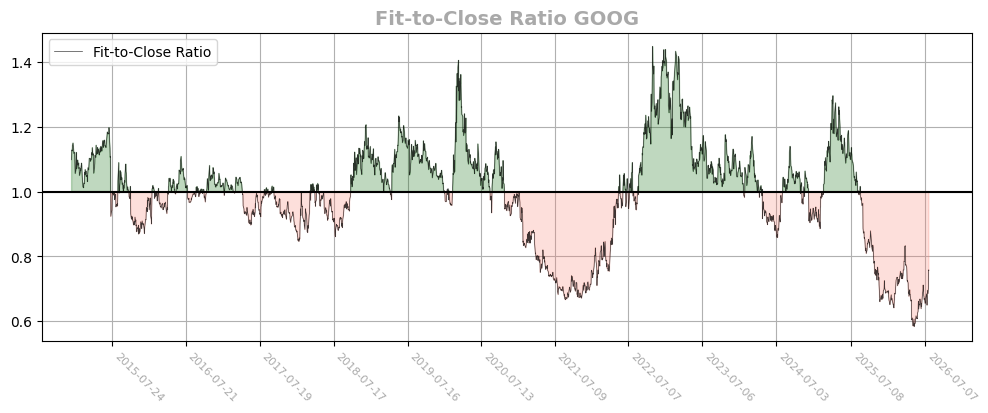

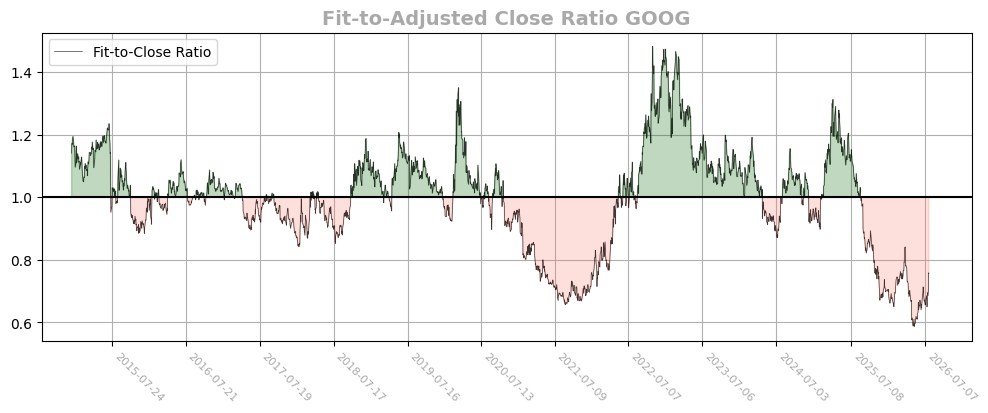

In [12]:
## Relative Close Plot
fig = plt.figure(figsize=(12., 4.0))
ax = fig.gca()
#
ax.set_title("Fit-to-Close Ratio GOOG", fontsize=14, fontweight="bold", color="darkgrey")
x = day[strt_day_idx + 1:]
y = np.exp(fit_points) / close[strt_day_idx + 1:]
ax.plot(x, y, lw=0.5, color="black", alpha=0.75, label="Fit-to-Close Ratio")
ax.fill_between(x, 1.0, y, where=(y > 1.0), color="darkgreen", alpha=0.25)
ax.fill_between(x, 1.0, y, where=(y < 1.0), color="salmon", alpha=0.25)
ax.axhline(y = 1.0, color="black", linestyle="-", lw=1.5)
ax.legend(loc="upper left")
ax.set_xticks(day[::250])
ax.set_xticklabels(dates[::250], fontsize=8, color="darkgrey", rotation=-45, ha="left", va="top")
ax.grid()
ax.set_axisbelow(True)
ax.set_xlim(day[strt_day_idx-100],)
#
plt.show()


## GDP-Adjusted Relative Close Plot
fig = plt.figure(figsize=(12., 4.0))
ax = fig.gca()
#
ax.set_title("Fit-to-Adjusted Close Ratio GOOG", fontsize=14, fontweight="bold", color="darkgrey")
x = day[strt_day_idx + 1:]
y = np.exp(adj_fit_points) / gdpdef_adj_close[strt_day_idx + 1:]
ax.plot(x, y, lw=0.5, color="black", alpha=0.75, label="Fit-to-Close Ratio")
ax.fill_between(x, 1.0, y, where=(y > 1.0), color="darkgreen", alpha=0.25)
ax.fill_between(x, 1.0, y, where=(y < 1.0), color="salmon", alpha=0.25)
ax.axhline(y = 1.0, color="black", linestyle="-", lw=1.5)
ax.legend(loc="upper left")
ax.set_xticks(day[::250])
ax.set_xticklabels(dates[::250], fontsize=8, color="darkgrey", rotation=-45, ha="left", va="top")
ax.grid()
ax.set_axisbelow(True)
ax.set_xlim(day[strt_day_idx-100],)
#
plt.show()

## Simple Averaging of the Log Returns:

In [13]:
# close = goog_df["Close"].to_numpy()
# day = goog_df["Day"].to_numpy()[:-1]
# dates = goog_df["Date"].to_numpy()[:-1]
# log_return = np.log(close[1:] / close[:-1])

# print("Log Return Mean & STD :")
# log_returns_in_range = log_return[strt_day_idx:end_day_idx]
# est_err = log_returns_in_range.std() / np.sqrt(log_returns_in_range.size)
# print(" - Daily Mean:  ", np.around(log_returns_in_range.mean(), 7), "±", np.around(est_err, 7))
# print(" - Daily STD:   ", np.around(log_returns_in_range.std(), 7))
# annual_low = np.power(1.0 + log_returns_in_range.mean() - est_err, 365) - 1.0
# annual_high = np.power(1.0 + log_returns_in_range.mean() + est_err, 365) - 1.0
# print("\nEst. Annual Growth: ", np.around(annual_low, 4), " to ", np.around(annual_high, 4))

# fig = plt.figure(figsize=(12., 5.0))
# ax = fig.gca()
# #
# ax.set_title("Log Return", fontsize=14, fontweight="bold", color="darkgrey")
# ax.plot(day[:strt_day_idx], log_return[:strt_day_idx], lw=0.5, color="darkgrey", alpha=0.5)
# ax.plot(day[strt_day_idx:end_day_idx], log_return[strt_day_idx:end_day_idx], 
#         lw=0.5, color="steelblue", alpha=0.5)
# ax.plot(day[end_day_idx:], log_return[end_day_idx:], lw=0.5, color="darkgrey", alpha=0.5)
# ax.set_xticks(day[::250])
# ax.set_xticklabels(dates[::250], fontsize=8, color="darkgrey", rotation=-45, ha="left", va="top")
# ax.grid()
# ax.set_axisbelow(True)
# #
# plt.show()

## Cummulative Gain During Period:

In [14]:
# day = goog_df["Day"].to_numpy()
# low = goog_df["Low"].to_numpy()
# high = goog_df["High"].to_numpy()
# close = goog_df["Close"].to_numpy()
# dates = goog_df["Date"].to_numpy()

# cumm_strt_date = "2018-01-01"
# cumm_end_date =  "2023-01-01"
# cumm_target_date = goog_df['Date'].iloc[-1]

# cumm_strt_day_idx = goog_df.index[goog_df["DATETIME"] >= cumm_strt_date][0]
# cumm_end_day_idx = goog_df.index[goog_df["DATETIME"] > cumm_end_date][0]
# cumm_target_day_idx = goog_df.index[goog_df["DATETIME"] >= cumm_target_date][0]

# print("Dates:")
# print(f"\tStart Date:  {goog_df['Date'].iloc[cumm_strt_day_idx]}")
# print(f"\tEnd Date:    {goog_df['Date'].iloc[cumm_end_day_idx]}")
# print(f"\tTarget Date: {goog_df['Date'].iloc[cumm_target_day_idx]}")

In [15]:
# # Compute number of shares if purchased daily with a fix amount:
# low_num_shares = np.sum(1.0 / high[cumm_strt_day_idx:cumm_end_day_idx])
# high_num_shares = np.sum(1.0 / low[cumm_strt_day_idx:cumm_end_day_idx])
# close_num_shares = np.sum(1.0 / close[cumm_strt_day_idx:cumm_end_day_idx])

# num_days = cumm_end_day_idx - cumm_strt_day_idx
# min_period_gain = low[cumm_target_day_idx] * low_num_shares / num_days
# max_period_gain = high[cumm_target_day_idx] * high_num_shares / num_days
# close_period_gain = close[cumm_target_day_idx] * close_num_shares / num_days

# print(f"\tMin Gain at Target:   {np.around(min_period_gain, 3)}")
# print(f"\tMax Gain at Target:   {np.around(max_period_gain, 3)}")
# print(f"\tClose Gain at Target: {np.around(close_period_gain, 3)}")

# annual_inflation_rate = 3.5
# inflation = np.power(1.0 + 0.01 * annual_inflation_rate, num_days / 365)
# print(f"\tInflation (at {annual_inflation_rate}% annual rate): {np.round(inflation, 2)}")

</br></br></br>

--------------------
# NASDAQ-100

In [16]:
ndx_df = pd.read_csv("csv_files/NDX.csv")

display(ndx_df.head(10))

,Date,Open,High,Low,Close,Adj Close,Volume
0,2026-07-24,28362.15,28471.48,28053.08,28128.34,28128.34,7266300000
1,2026-07-23,28545.98,28726.62,28274.52,28454.81,28454.81,7655810000
2,2026-07-22,28949.81,29176.91,28934.52,28998.10,28998.10,7473050000
3,2026-07-21,29059.44,29192.29,28891.07,29155.18,29155.18,8001540000
4,2026-07-20,28871.16,29017.23,28590.40,28604.23,28604.23,7184070000
5,2026-07-17,28457.33,28867.40,28231.32,28592.66,28592.66,7820470000
6,2026-07-16,29318.30,29333.06,28881.23,29025.77,29025.77,8294880000
7,2026-07-15,29759.80,29771.89,29192.89,29502.60,29502.60,7379560000
8,2026-07-14,29561.35,29693.77,29368.87,29586.29,29586.29,7397960000
9,2026-07-13,29471.02,29541.00,29189.21,29264.10,29264.10,7231310000


In [17]:
# Conver Date to DateTime Object:
ndx_df["DATETIME"] = pd.to_datetime(ndx_df["Date"], format="%Y-%m-%d")
ndx_df["Day"] = (ndx_df["DATETIME"] - pd.Timestamp.today()).dt.days

# Sort by ascending day:
ndx_df = ndx_df.sort_values(
    by="Day", ascending=True, ignore_index=True,
)

display(ndx_df.tail(10))

,Date,Open,High,Low,Close,Adj Close,Volume,DATETIME,Day
10272,2026-07-13,29471.02,29541.00,29189.21,29264.10,29264.10,7231310000,2026-07-13,-13
10273,2026-07-14,29561.35,29693.77,29368.87,29586.29,29586.29,7397960000,2026-07-14,-12
10274,2026-07-15,29759.80,29771.89,29192.89,29502.60,29502.60,7379560000,2026-07-15,-11
10275,2026-07-16,29318.30,29333.06,28881.23,29025.77,29025.77,8294880000,2026-07-16,-10
10276,2026-07-17,28457.33,28867.40,28231.32,28592.66,28592.66,7820470000,2026-07-17,-9
10277,2026-07-20,28871.16,29017.23,28590.40,28604.23,28604.23,7184070000,2026-07-20,-6
10278,2026-07-21,29059.44,29192.29,28891.07,29155.18,29155.18,8001540000,2026-07-21,-5
10279,2026-07-22,28949.81,29176.91,28934.52,28998.10,28998.10,7473050000,2026-07-22,-4
10280,2026-07-23,28545.98,28726.62,28274.52,28454.81,28454.81,7655810000,2026-07-23,-3
10281,2026-07-24,28362.15,28471.48,28053.08,28128.34,28128.34,7266300000,2026-07-24,-2


## Adjust by GDP Deflator:

In [18]:
# Merge DataFrames:
gdpdef_adj_ndx_df = pd.merge(
    left=ndx_df[["Close", "DATETIME", "Date", "Day"]],
    right=gdpdef_df[["GDPDEF", "DATETIME", "Date", "Day"]], 
    how="outer", sort=True, on="Day")

# Interpolate:
gdpdef_adj_ndx_df["GDPDEF"] = gdpdef_adj_ndx_df["GDPDEF"].interpolate(
    method="linear", limit_direction="forward", axis=0)

# Drop rows outside of Goog DATETIME
gdpdef_adj_ndx_df = gdpdef_adj_ndx_df[gdpdef_adj_ndx_df["Close"].notna()]

# Use the Goog DATETIME:
gdpdef_adj_ndx_df = gdpdef_adj_ndx_df.rename(columns={
        "DATETIME_x": "DATETIME",
        "Date_x": "Date"
})

# Drop columns:
gdpdef_adj_ndx_df = gdpdef_adj_ndx_df.drop(["DATETIME_y", "Date_y"], axis=1, inplace=False)

## Plot:

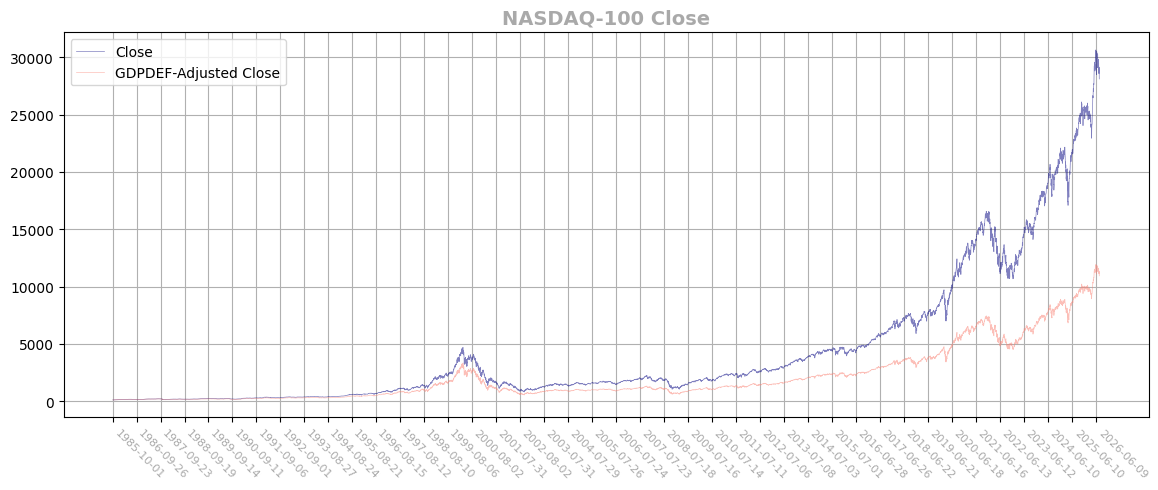

In [19]:
fig = plt.figure(figsize=(14., 5.0))
ax = fig.gca()

day = gdpdef_adj_ndx_df["Day"].to_numpy()
close = gdpdef_adj_ndx_df["Close"].to_numpy()
gdp_def = gdpdef_adj_ndx_df["GDPDEF"].to_numpy()
gdp_def = gdp_def / gdp_def[0]
dates = gdpdef_adj_ndx_df["Date"].to_numpy()

ax.set_title("NASDAQ-100 Close", fontsize=14, fontweight="bold", color="darkgrey")
# ax.plot(day, gdp_def, lw=0.5, color="navy", alpha=0.5, label="gdp_def")
ax.plot(day, close, lw=0.5, color="navy", alpha=0.5, label="Close")
ax.plot(day, close / gdp_def, lw=0.5, color="salmon", alpha=0.5, label="GDPDEF-Adjusted Close")
ax.legend(loc="upper left")
ax.set_xticks(day[::250])
ax.set_xticklabels(dates[::250], fontsize=8, color="darkgrey", rotation=-45, ha="left", va="top")
ax.grid()
ax.set_axisbelow(True)

plt.show()

## Fit to Historical Close Prices:

In [20]:
day = gdpdef_adj_ndx_df["Day"].to_numpy()
close = gdpdef_adj_ndx_df["Close"].to_numpy()
gdp_def = gdpdef_adj_ndx_df["GDPDEF"].to_numpy()
gdp_def = gdp_def / gdp_def[0]
gdpdef_adj_close = close / gdp_def
dates = gdpdef_adj_ndx_df["Date"].to_numpy()
log_close = np.log(close)
log_gdpdef_adj_close = np.log(gdpdef_adj_close)

strt_date = "2015-01-01"
end_date =  "2025-01-01"
target_date = ndx_df['Date'].iloc[-1]

strt_day_idx = ndx_df.index[ndx_df["DATETIME"] >= strt_date][0]
end_day_idx = ndx_df.index[ndx_df["DATETIME"] > end_date][0]
target_day_idx = ndx_df.index[ndx_df["DATETIME"] >= target_date][0]

print("Dates:")
print(f"\tStart Date:  {ndx_df['Date'].iloc[strt_day_idx]}")
print(f"\tEnd Date:    {ndx_df['Date'].iloc[end_day_idx]}")
print(f"\tTarget Date: {ndx_df['Date'].iloc[target_day_idx]}")

Dates:
	Start Date:  2015-01-02
	End Date:    2025-01-02
	Target Date: 2026-07-24


In [21]:
fit_results = linregress(day[strt_day_idx:end_day_idx], log_close[strt_day_idx:end_day_idx])
fit_points = fit_results[0] * day[strt_day_idx:target_day_idx] + fit_results[1]

adj_fit_results = linregress(day[strt_day_idx:end_day_idx], log_gdpdef_adj_close[strt_day_idx:end_day_idx])
adj_fit_points = adj_fit_results[0] * day[strt_day_idx:target_day_idx] + adj_fit_results[1]

print("\tSlope:       ", np.around(fit_results[0], 7))
print("\tIntercept:   ", np.around(fit_results[1], 7))
# print("\tExp Slope: ", np.around(np.exp(fit_results[0]), 7))
print("\tEst. Annual: ", np.around(np.power(1.0 + fit_results[0], 365) - 1.0, 7))
max_log_delta = np.max(log_close[strt_day_idx:target_day_idx] - fit_points)
print("Ratio of Expected to Current: ", np.around(np.exp(fit_points[-1] - log_close[target_day_idx]), 7))
print("Max Deviation:                ", np.around(np.exp(max_log_delta), 7))

print("\nProjected Price:              ", np.around(np.exp(fit_points[-1]), 3))

	Slope:        0.0004558
	Intercept:    10.1858579
	Est. Annual:  0.1809541
Ratio of Expected to Current:  0.9417246
Max Deviation:                 1.3621723

Projected Price:               26489.151


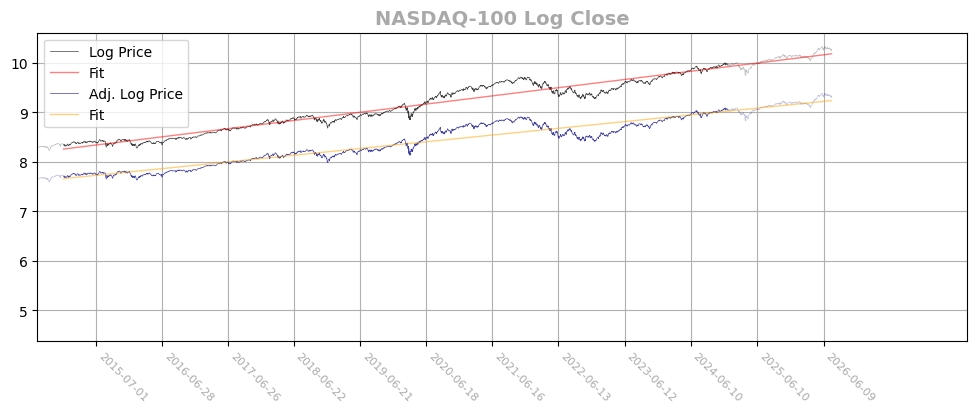

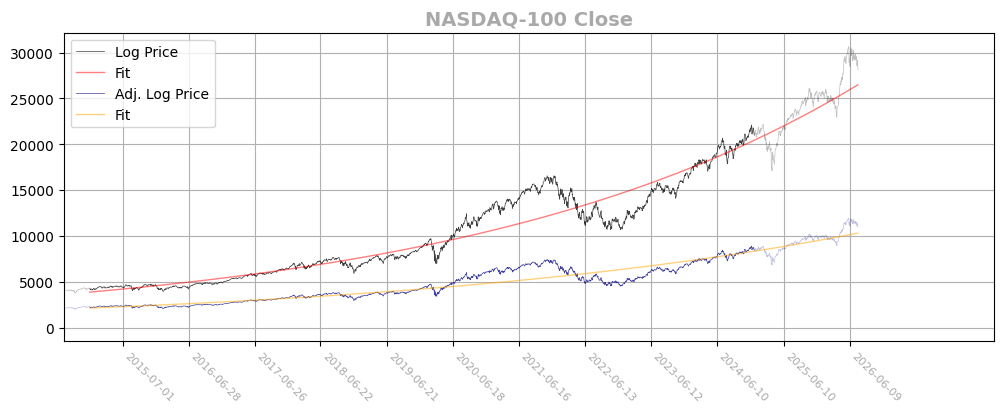

In [22]:
## Log Close Plot
fig = plt.figure(figsize=(12., 4.0))
ax = fig.gca()
#
ax.set_title("NASDAQ-100 Log Close", fontsize=14, fontweight="bold", color="darkgrey")
ax.plot(day[strt_day_idx:end_day_idx], log_close[strt_day_idx:end_day_idx], 
        lw=0.5, color="black", alpha=0.75, label="Log Price")
ax.plot(day[:strt_day_idx], log_close[:strt_day_idx], lw=0.5, color="black", alpha=0.25, label=None)
ax.plot(day[end_day_idx:], log_close[end_day_idx:], lw=0.5, color="black", alpha=0.25, label=None)
ax.plot(day[strt_day_idx:target_day_idx], fit_points, lw=1.0, color="red", alpha=0.5, label="Fit")
#
ax.plot(day[strt_day_idx:end_day_idx], log_gdpdef_adj_close[strt_day_idx:end_day_idx], 
        lw=0.5, color="navy", alpha=0.75, label="Adj. Log Price")
ax.plot(day[:strt_day_idx], log_gdpdef_adj_close[:strt_day_idx], lw=0.5, color="navy", alpha=0.25, label=None)
ax.plot(day[end_day_idx:], log_gdpdef_adj_close[end_day_idx:], lw=0.5, color="navy", alpha=0.25, label=None)
ax.plot(day[strt_day_idx:target_day_idx], adj_fit_points, lw=1.0, color="orange", alpha=0.5, label="Fit")
#
ax.legend(loc="upper left")
ax.set_xticks(day[::250])
ax.set_xticklabels(dates[::250], fontsize=8, color="darkgrey", rotation=-45, ha="left", va="top")
ax.grid()
ax.set_axisbelow(True)
ax.set_xlim(day[strt_day_idx-100],)
#
plt.show()


## Close Plot
fig = plt.figure(figsize=(12., 4.0))
ax = fig.gca()
#
ax.set_title("NASDAQ-100 Close", fontsize=14, fontweight="bold", color="darkgrey")
ax.plot(day[strt_day_idx:end_day_idx], close[strt_day_idx:end_day_idx], 
        lw=0.5, color="black", alpha=0.75, label="Log Price")
ax.plot(day[:strt_day_idx], close[:strt_day_idx], lw=0.5, color="black", alpha=0.25, label=None)
ax.plot(day[end_day_idx:], close[end_day_idx:], lw=0.5, color="black", alpha=0.25, label=None)
ax.plot(day[strt_day_idx:target_day_idx], np.exp(fit_points), lw=1.0, color="red", alpha=0.5, label="Fit")
#
ax.plot(day[strt_day_idx:end_day_idx], gdpdef_adj_close[strt_day_idx:end_day_idx], 
        lw=0.5, color="navy", alpha=0.75, label="Adj. Log Price")
ax.plot(day[:strt_day_idx], gdpdef_adj_close[:strt_day_idx], lw=0.5, color="navy", alpha=0.25, label=None)
ax.plot(day[end_day_idx:], gdpdef_adj_close[end_day_idx:], lw=0.5, color="navy", alpha=0.25, label=None)
ax.plot(day[strt_day_idx:target_day_idx], np.exp(adj_fit_points), lw=1.0, color="orange", alpha=0.5, label="Fit")
#
ax.legend(loc="upper left")
ax.set_xticks(day[::250])
ax.set_xticklabels(dates[::250], fontsize=8, color="darkgrey", rotation=-45, ha="left", va="top")
ax.grid()
ax.set_axisbelow(True)
ax.set_xlim(day[strt_day_idx-100],)
#
plt.show()

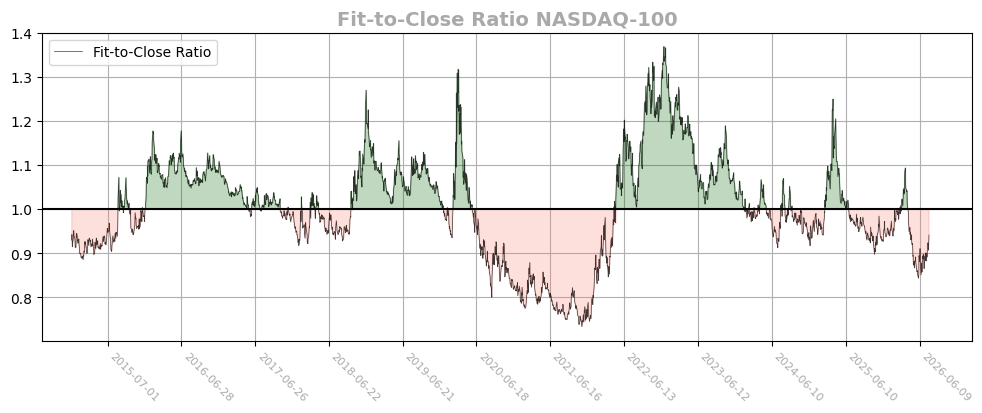

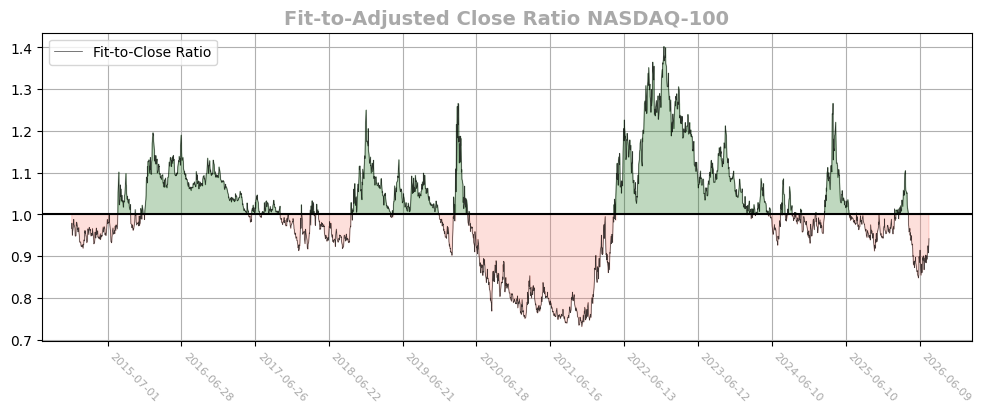

In [23]:
## Relative Close Plot
fig = plt.figure(figsize=(12., 4.0))
ax = fig.gca()
#
ax.set_title("Fit-to-Close Ratio NASDAQ-100", fontsize=14, fontweight="bold", color="darkgrey")
x = day[strt_day_idx + 1:]
y = np.exp(fit_points) / close[strt_day_idx + 1:]
ax.plot(x, y, lw=0.5, color="black", alpha=0.75, label="Fit-to-Close Ratio")
ax.fill_between(x, 1.0, y, where=(y > 1.0), color="darkgreen", alpha=0.25)
ax.fill_between(x, 1.0, y, where=(y < 1.0), color="salmon", alpha=0.25)
ax.axhline(y = 1.0, color="black", linestyle="-", lw=1.5)
ax.legend(loc="upper left")
ax.set_xticks(day[::250])
ax.set_xticklabels(dates[::250], fontsize=8, color="darkgrey", rotation=-45, ha="left", va="top")
ax.grid()
ax.set_axisbelow(True)
ax.set_xlim(day[strt_day_idx-100],)
#
plt.show()


## GDP-Adjusted Relative Close Plot
fig = plt.figure(figsize=(12., 4.0))
ax = fig.gca()
#
ax.set_title("Fit-to-Adjusted Close Ratio NASDAQ-100", fontsize=14, fontweight="bold", color="darkgrey")
x = day[strt_day_idx + 1:]
y = np.exp(adj_fit_points) / gdpdef_adj_close[strt_day_idx + 1:]
ax.plot(x, y, lw=0.5, color="black", alpha=0.75, label="Fit-to-Close Ratio")
ax.fill_between(x, 1.0, y, where=(y > 1.0), color="darkgreen", alpha=0.25)
ax.fill_between(x, 1.0, y, where=(y < 1.0), color="salmon", alpha=0.25)
ax.axhline(y = 1.0, color="black", linestyle="-", lw=1.5)
ax.legend(loc="upper left")
ax.set_xticks(day[::250])
ax.set_xticklabels(dates[::250], fontsize=8, color="darkgrey", rotation=-45, ha="left", va="top")
ax.grid()
ax.set_axisbelow(True)
ax.set_xlim(day[strt_day_idx-100],)
#
plt.show()

## Simple Averaging of the Log Returns:

In [24]:
# close = ndx_df["Close"].to_numpy()
# day = ndx_df["Day"].to_numpy()[:-1]
# dates = ndx_df["Date"].to_numpy()[:-1]
# log_return = np.log(close[1:] / close[:-1])

# print("Log Return Mean & STD :")
# log_returns_in_range = log_return[strt_day_idx:end_day_idx]
# est_err = log_returns_in_range.std() / np.sqrt(log_returns_in_range.size)
# print(" - Mean: ", np.around(log_returns_in_range.mean(), 7), "±", np.around(est_err, 7))
# print(" - STD:  ", np.around(log_returns_in_range.std(), 7))

# fig = plt.figure(figsize=(12., 5.0))
# ax = fig.gca()
# #
# ax.set_title("Log Return", fontsize=14, fontweight="bold", color="darkgrey")
# ax.plot(day[:strt_day_idx], log_return[:strt_day_idx], lw=0.5, color="darkgrey", alpha=0.5)
# ax.plot(day[strt_day_idx:end_day_idx], log_return[strt_day_idx:end_day_idx], 
#         lw=0.5, color="steelblue", alpha=0.5)
# ax.plot(day[end_day_idx:], log_return[end_day_idx:], lw=0.5, color="darkgrey", alpha=0.5)
# ax.set_xticks(day[::250])
# ax.set_xticklabels(dates[::250], fontsize=8, color="darkgrey", rotation=-45, ha="left", va="top")
# ax.grid()
# ax.set_axisbelow(True)
# #
# plt.show()

## Cummulative Gain During Period:

In [25]:
# day = ndx_df["Day"].to_numpy()
# low = ndx_df["Low"].to_numpy()
# high = ndx_df["High"].to_numpy()
# close = ndx_df["Close"].to_numpy()
# dates = ndx_df["Date"].to_numpy()

# cumm_strt_date = "2018-01-01"
# cumm_end_date =  "2023-01-01"
# cumm_target_date = ndx_df['Date'].iloc[-1]

# cumm_strt_day_idx = ndx_df.index[ndx_df["DATETIME"] >= cumm_strt_date][0]
# cumm_end_day_idx = ndx_df.index[ndx_df["DATETIME"] > cumm_end_date][0]
# cumm_target_day_idx = ndx_df.index[ndx_df["DATETIME"] >= cumm_target_date][0]

# print("Dates:")
# print(f"\tStart Date:  {ndx_df['Date'].iloc[cumm_strt_day_idx]}")
# print(f"\tEnd Date:    {ndx_df['Date'].iloc[cumm_end_day_idx]}")
# print(f"\tTarget Date: {ndx_df['Date'].iloc[cumm_target_day_idx]}")

In [26]:
# # Compute number of shares if purchased daily with a fix amount:
# low_num_shares = np.sum(1.0 / high[cumm_strt_day_idx:cumm_end_day_idx])
# high_num_shares = np.sum(1.0 / low[cumm_strt_day_idx:cumm_end_day_idx])
# close_num_shares = np.sum(1.0 / close[cumm_strt_day_idx:cumm_end_day_idx])

# num_days = cumm_end_day_idx - cumm_strt_day_idx
# min_period_gain = low[cumm_target_day_idx] * low_num_shares / num_days
# max_period_gain = high[cumm_target_day_idx] * high_num_shares / num_days
# close_period_gain = close[cumm_target_day_idx] * close_num_shares / num_days

# print(f"\tMin Gain at Target:   {np.around(min_period_gain, 3)}")
# print(f"\tMax Gain at Target:   {np.around(max_period_gain, 3)}")
# print(f"\tClose Gain at Target: {np.around(close_period_gain, 3)}")

# annual_inflation_rate = 3.5
# inflation = np.power(1.0 + 0.01 * annual_inflation_rate, num_days / 365)
# print(f"\tInflation (at {annual_inflation_rate}% annual rate): {np.round(inflation, 2)}")

</br></br></br>

--------------------
# Dow Jones

In [27]:
dji_df = pd.read_csv("csv_files/DJI.csv")

display(dji_df.head(10))
display(len(dji_df.index))

,Date,Open,High,Low,Close,Adj Close,Volume
0,2026-07-24,51791.37,52118.19,51682.36,51947.25,51947.25,437530000
1,2026-07-23,51755.54,51885.14,51542.06,51711.65,51711.65,496570000
2,2026-07-22,52287.14,52511.21,52148.87,52218.58,52218.58,449100000
3,2026-07-21,51916.79,52370.65,51890.10,52224.64,52224.64,404610000
4,2026-07-20,52154.57,52411.90,51781.90,51839.26,51839.26,397690000
5,2026-07-17,52426.46,52610.97,51986.74,52146.42,52146.42,549690000
6,2026-07-16,52924.86,52924.86,52367.42,52552.97,52552.97,528320000
7,2026-07-15,52604.20,52823.95,52428.54,52658.64,52658.64,506020000
8,2026-07-14,52046.36,52695.06,52046.36,52508.27,52508.27,464870000
9,2026-07-13,52676.53,52846.51,52351.12,52498.64,52498.64,399240000


8701

In [28]:
# Remove duplicates:
dji_df = dji_df.drop_duplicates("Date")
display(len(dji_df.index))

# Reset Index:
dji_df.reset_index(drop=True, inplace=True)

8701

In [29]:
# Conver Date to DateTime Object:
dji_df["DATETIME"] = pd.to_datetime(dji_df["Date"], format="%Y-%m-%d")
dji_df["Day"] = (dji_df["DATETIME"] - pd.Timestamp.today()).dt.days

# Sort by ascending day:
dji_df = dji_df.sort_values(
    by="Day", ascending=True, ignore_index=True,
)

display(dji_df.head(10))
display(len(dji_df.index))

,Date,Open,High,Low,Close,Adj Close,Volume,DATETIME,Day
0,1992-01-02,3152.100098,3172.629883,3139.310059,3172.399902,3172.399902,23550000,1992-01-02,-12624
1,1992-01-03,3172.399902,3210.639893,3165.919922,3201.500000,3201.500000,23620000,1992-01-03,-12623
2,1992-01-06,3201.500000,3213.330078,3191.860107,3200.100098,3200.100098,27280000,1992-01-06,-12620
3,1992-01-07,3200.100098,3210.199951,3184.479980,3204.800049,3204.800049,25510000,1992-01-07,-12619
4,1992-01-08,3204.800049,3229.199951,3185.820068,3203.899902,3203.899902,29040000,1992-01-08,-12618
5,1992-01-09,3203.899902,3228.310059,3192.750000,3209.500000,3209.500000,29820000,1992-01-09,-12617
6,1992-01-10,3209.500000,3217.129883,3185.379883,3199.500000,3199.500000,23440000,1992-01-10,-12616
7,1992-01-13,3199.500000,3201.250000,3179.110107,3185.600098,3185.600098,19300000,1992-01-13,-12613
8,1992-01-14,3185.600098,3248.879883,3182.919922,3246.199951,3246.199951,24220000,1992-01-14,-12612
9,1992-01-15,3246.199951,3263.419922,3232.110107,3258.500000,3258.500000,29560000,1992-01-15,-12611


8701

## Adjust by GDP Deflator:

In [30]:
# Merge DataFrames:
gdpdef_adj_dji_df = pd.merge(
    left=dji_df[["Close", "DATETIME", "Date", "Day"]],
    right=gdpdef_df[["GDPDEF", "DATETIME", "Date", "Day"]], 
    how="outer", sort=True, on="Day")

# Interpolate:
gdpdef_adj_dji_df["GDPDEF"] = gdpdef_adj_dji_df["GDPDEF"].interpolate(
    method="linear", limit_direction="forward", axis=0)

# Drop rows outside of Goog DATETIME
gdpdef_adj_dji_df = gdpdef_adj_dji_df[gdpdef_adj_dji_df["Close"].notna()]

# Use the Goog DATETIME:
gdpdef_adj_dji_df = gdpdef_adj_dji_df.rename(columns={
        "DATETIME_x": "DATETIME",
        "Date_x": "Date"
})

# Drop columns:
gdpdef_adj_dji_df = gdpdef_adj_dji_df.drop(["DATETIME_y", "Date_y"], axis=1, inplace=False)

## Plot:

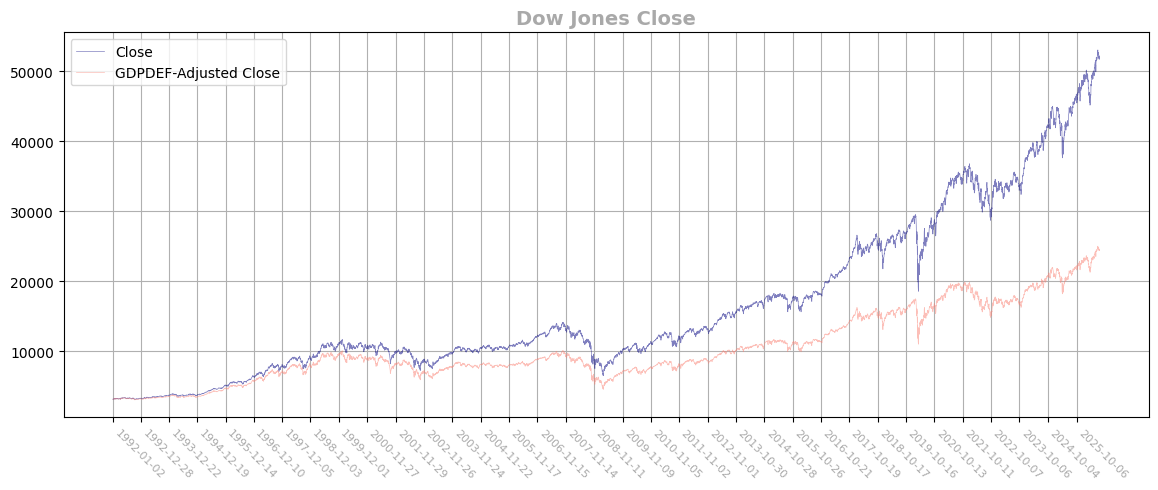

In [31]:
fig = plt.figure(figsize=(14., 5.0))
ax = fig.gca()

day = gdpdef_adj_dji_df["Day"].to_numpy()
close = gdpdef_adj_dji_df["Close"].to_numpy()
gdp_def = gdpdef_adj_dji_df["GDPDEF"].to_numpy()
gdp_def = gdp_def / gdp_def[0]
dates = gdpdef_adj_dji_df["Date"].to_numpy()

ax.set_title("Dow Jones Close", fontsize=14, fontweight="bold", color="darkgrey")
# ax.plot(day, gdp_def, lw=0.5, color="navy", alpha=0.5, label="gdp_def")
ax.plot(day, close, lw=0.5, color="navy", alpha=0.5, label="Close")
ax.plot(day, close / gdp_def, lw=0.5, color="salmon", alpha=0.5, label="GDPDEF-Adjusted Close")
ax.legend(loc="upper left")
ax.set_xticks(day[::250])
ax.set_xticklabels(dates[::250], fontsize=8, color="darkgrey", rotation=-45, ha="left", va="top")
ax.grid()
ax.set_axisbelow(True)

plt.show()


## Fit to Historical Close Prices:

In [32]:
day = gdpdef_adj_dji_df["Day"].to_numpy()
close = gdpdef_adj_dji_df["Close"].to_numpy()
gdp_def = gdpdef_adj_dji_df["GDPDEF"].to_numpy()
gdp_def = gdp_def / gdp_def[0]
gdpdef_adj_close = close / gdp_def
dates = gdpdef_adj_dji_df["Date"].to_numpy()
log_close = np.log(close)
log_gdpdef_adj_close = np.log(gdpdef_adj_close)

strt_date = "2015-01-01"
end_date =  "2025-01-01"
target_date = dji_df['Date'].iloc[-1]

strt_day_idx = dji_df.index[dji_df["DATETIME"] >= strt_date][0]
end_day_idx = dji_df.index[dji_df["DATETIME"] > end_date][0]
target_day_idx = dji_df.index[dji_df["DATETIME"] >= target_date][0]

print("Dates:")
print(f"\tStart Date:  {dji_df['Date'].iloc[strt_day_idx]}")
print(f"\tEnd Date:    {dji_df['Date'].iloc[end_day_idx]}")
print(f"\tTarget Date: {dji_df['Date'].iloc[target_day_idx]}")

Dates:
	Start Date:  2015-01-02
	End Date:    2025-01-02
	Target Date: 2026-07-24


In [33]:
fit_results = linregress(day[strt_day_idx:end_day_idx], log_close[strt_day_idx:end_day_idx])
fit_points = fit_results[0] * day[strt_day_idx:target_day_idx] + fit_results[1]

adj_fit_results = linregress(day[strt_day_idx:end_day_idx], log_gdpdef_adj_close[strt_day_idx:end_day_idx])
adj_fit_points = adj_fit_results[0] * day[strt_day_idx:target_day_idx] + adj_fit_results[1]

print("\tSlope:       ", np.around(fit_results[0], 7))
print("\tIntercept:   ", np.around(fit_results[1], 7))
# print("\tExp Slope:   ", np.around(np.exp(fit_results[0]), 7))
print("\tEst. Annual: ", np.around(np.power(1.0 + fit_results[0], 365) - 1.0, 7))
max_log_delta = np.max(log_close[strt_day_idx:target_day_idx]-fit_points)
print("Ratio of Expected to Current: ", np.around(np.exp(fit_points[-1] - log_close[target_day_idx]), 7))
print("Max Deviation:                ", np.around(np.exp(max_log_delta), 7))

print("\nProjected Price:              ", np.around(np.exp(fit_points[-1]), 3))

	Slope:        0.0002486
	Intercept:    10.7889542
	Est. Annual:  0.0949571
Ratio of Expected to Current:  0.9326031
Max Deviation:                 1.1872494

Projected Price:               48446.166


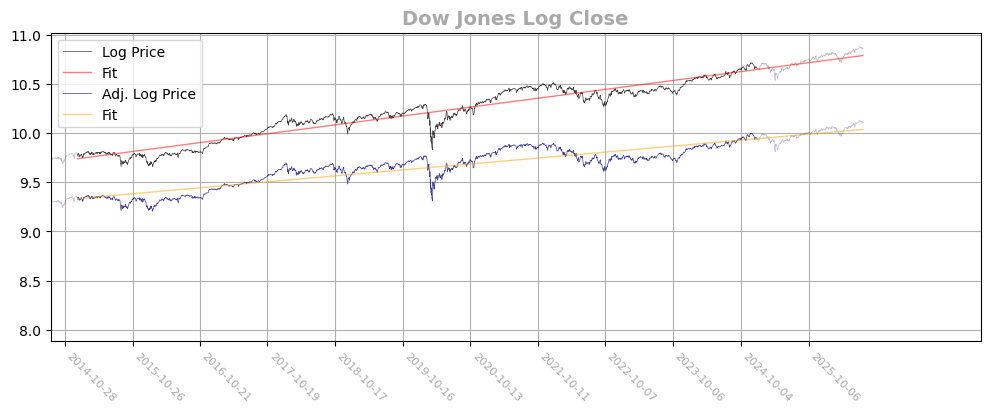

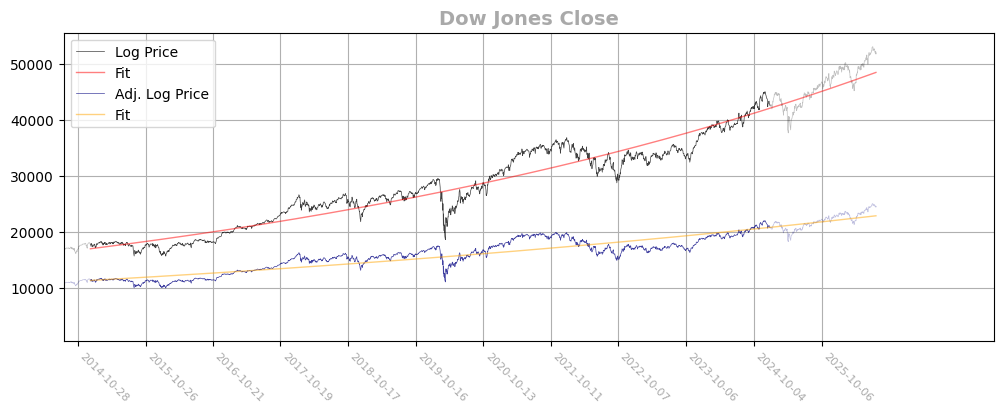

In [34]:
## Log Close Plot
fig = plt.figure(figsize=(12., 4.0))
ax = fig.gca()
#
ax.set_title("Dow Jones Log Close", fontsize=14, fontweight="bold", color="darkgrey")
ax.plot(day[strt_day_idx:end_day_idx], log_close[strt_day_idx:end_day_idx], 
        lw=0.5, color="black", alpha=0.75, label="Log Price")
ax.plot(day[:strt_day_idx], log_close[:strt_day_idx], lw=0.5, color="black", alpha=0.25, label=None)
ax.plot(day[end_day_idx:], log_close[end_day_idx:], lw=0.5, color="black", alpha=0.25, label=None)
ax.plot(day[strt_day_idx:target_day_idx], fit_points, lw=1.0, color="red", alpha=0.5, label="Fit")
#
ax.plot(day[strt_day_idx:end_day_idx], log_gdpdef_adj_close[strt_day_idx:end_day_idx], 
        lw=0.5, color="navy", alpha=0.75, label="Adj. Log Price")
ax.plot(day[:strt_day_idx], log_gdpdef_adj_close[:strt_day_idx], lw=0.5, color="navy", alpha=0.25, label=None)
ax.plot(day[end_day_idx:], log_gdpdef_adj_close[end_day_idx:], lw=0.5, color="navy", alpha=0.25, label=None)
ax.plot(day[strt_day_idx:target_day_idx], adj_fit_points, lw=1.0, color="orange", alpha=0.5, label="Fit")
#
ax.legend(loc="upper left")
ax.set_xticks(day[::250])
ax.set_xticklabels(dates[::250], fontsize=8, color="darkgrey", rotation=-45, ha="left", va="top")
ax.grid()
ax.set_axisbelow(True)
ax.set_xlim(day[strt_day_idx-100],)
#
plt.show()


## Close Plot
fig = plt.figure(figsize=(12., 4.0))
ax = fig.gca()
#
ax.set_title("Dow Jones Close", fontsize=14, fontweight="bold", color="darkgrey")
ax.plot(day[strt_day_idx:end_day_idx], close[strt_day_idx:end_day_idx], 
        lw=0.5, color="black", alpha=0.75, label="Log Price")
ax.plot(day[:strt_day_idx], close[:strt_day_idx], lw=0.5, color="black", alpha=0.25, label=None)
ax.plot(day[end_day_idx:], close[end_day_idx:], lw=0.5, color="black", alpha=0.25, label=None)
ax.plot(day[strt_day_idx:target_day_idx], np.exp(fit_points), lw=1.0, color="red", alpha=0.5, label="Fit")
#
ax.plot(day[strt_day_idx:end_day_idx], gdpdef_adj_close[strt_day_idx:end_day_idx], 
        lw=0.5, color="navy", alpha=0.75, label="Adj. Log Price")
ax.plot(day[:strt_day_idx], gdpdef_adj_close[:strt_day_idx], lw=0.5, color="navy", alpha=0.25, label=None)
ax.plot(day[end_day_idx:], gdpdef_adj_close[end_day_idx:], lw=0.5, color="navy", alpha=0.25, label=None)
ax.plot(day[strt_day_idx:target_day_idx], np.exp(adj_fit_points), lw=1.0, color="orange", alpha=0.5, label="Fit")
#
ax.legend(loc="upper left")
ax.set_xticks(day[::250])
ax.set_xticklabels(dates[::250], fontsize=8, color="darkgrey", rotation=-45, ha="left", va="top")
ax.grid()
ax.set_axisbelow(True)
ax.set_xlim(day[strt_day_idx-100],)
#
plt.show()

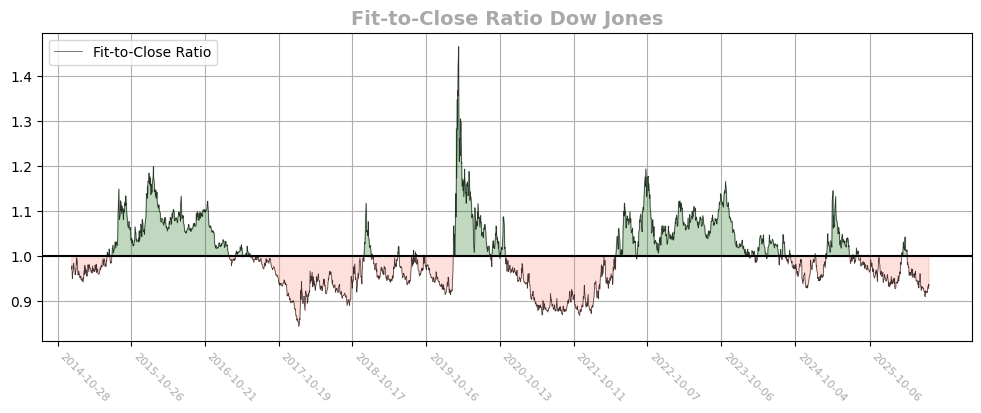

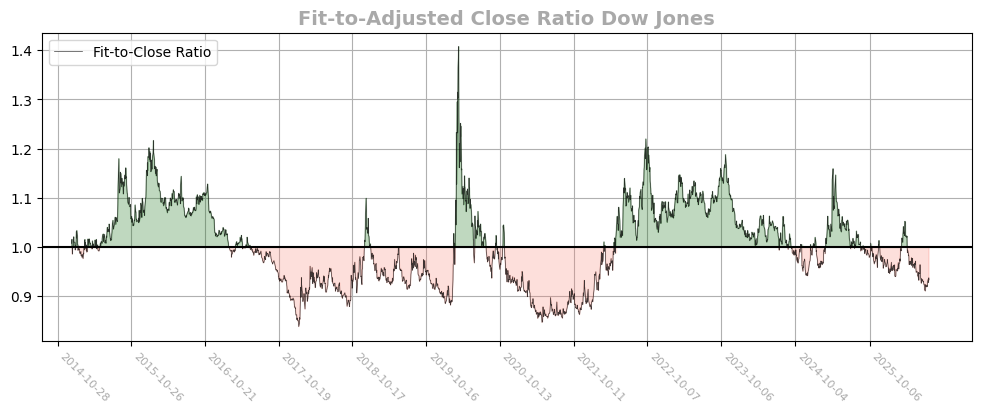

In [35]:
## Relative Close Plot
fig = plt.figure(figsize=(12., 4.0))
ax = fig.gca()
#
ax.set_title("Fit-to-Close Ratio Dow Jones", fontsize=14, fontweight="bold", color="darkgrey")
x = day[strt_day_idx + 1:]
y = np.exp(fit_points) / close[strt_day_idx + 1:]
ax.plot(x, y, lw=0.5, color="black", alpha=0.75, label="Fit-to-Close Ratio")
ax.fill_between(x, 1.0, y, where=(y > 1.0), color="darkgreen", alpha=0.25)
ax.fill_between(x, 1.0, y, where=(y < 1.0), color="salmon", alpha=0.25)
ax.axhline(y = 1.0, color="black", linestyle="-", lw=1.5)
ax.legend(loc="upper left")
ax.set_xticks(day[::250])
ax.set_xticklabels(dates[::250], fontsize=8, color="darkgrey", rotation=-45, ha="left", va="top")
ax.grid()
ax.set_axisbelow(True)
ax.set_xlim(day[strt_day_idx-100],)
#
plt.show()


## GDP-Adjusted Relative Close Plot
fig = plt.figure(figsize=(12., 4.0))
ax = fig.gca()
#
ax.set_title("Fit-to-Adjusted Close Ratio Dow Jones", fontsize=14, fontweight="bold", color="darkgrey")
x = day[strt_day_idx + 1:]
y = np.exp(adj_fit_points) / gdpdef_adj_close[strt_day_idx + 1:]
ax.plot(x, y, lw=0.5, color="black", alpha=0.75, label="Fit-to-Close Ratio")
ax.fill_between(x, 1.0, y, where=(y > 1.0), color="darkgreen", alpha=0.25)
ax.fill_between(x, 1.0, y, where=(y < 1.0), color="salmon", alpha=0.25)
ax.axhline(y = 1.0, color="black", linestyle="-", lw=1.5)
ax.legend(loc="upper left")
ax.set_xticks(day[::250])
ax.set_xticklabels(dates[::250], fontsize=8, color="darkgrey", rotation=-45, ha="left", va="top")
ax.grid()
ax.set_axisbelow(True)
ax.set_xlim(day[strt_day_idx-100],)
#
plt.show()

## Simple Averaging of Log Returns:

In [36]:
# close = dji_df["Close"].to_numpy()
# day = dji_df["Day"].to_numpy()[:-1]
# dates = dji_df["Date"].to_numpy()[:-1]
# log_return = np.log(close[1:] / close[:-1])

# print("Log Return Mean & STD :")
# log_returns_in_range = log_return[strt_day_idx:end_day_idx]
# est_err = log_returns_in_range.std() / np.sqrt(log_returns_in_range.size)
# print(" - Mean: ", np.around(log_returns_in_range.mean(), 7), "±", np.around(est_err, 7))
# print(" - STD:  ", np.around(log_returns_in_range.std(), 7))


# fig = plt.figure(figsize=(12., 4.0))
# ax = fig.gca()
# #
# ax.set_title("Log Return", fontsize=14, fontweight="bold", color="darkgrey")
# ax.plot(day[:strt_day_idx], log_return[:strt_day_idx], lw=0.5, color="darkgrey", alpha=0.5)
# ax.plot(day[strt_day_idx:end_day_idx], log_return[strt_day_idx:end_day_idx], 
#         lw=0.5, color="steelblue", alpha=0.5)
# ax.plot(day[end_day_idx:], log_return[end_day_idx:], lw=0.5, color="darkgrey", alpha=0.5)
# ax.set_xticks(day[::250])
# ax.set_xticklabels(dates[::250], fontsize=8, color="darkgrey", rotation=-45, ha="left", va="top")
# ax.grid()
# ax.set_axisbelow(True)
# #
# plt.show()

## Cummulative Gain During Period:

In [37]:
# day = dji_df["Day"].to_numpy()
# low = dji_df["Low"].to_numpy()
# high = dji_df["High"].to_numpy()
# close = dji_df["Close"].to_numpy()
# dates = dji_df["Date"].to_numpy()

# cumm_strt_date = "2018-01-01"
# cumm_end_date =  "2023-01-01"
# cumm_target_date = dji_df['Date'].iloc[-1]

# cumm_strt_day_idx = dji_df.index[dji_df["DATETIME"] >= cumm_strt_date][0]
# cumm_end_day_idx = dji_df.index[dji_df["DATETIME"] > cumm_end_date][0]
# cumm_target_day_idx = dji_df.index[dji_df["DATETIME"] >= cumm_target_date][0]

# print("Dates:")
# print(f"\tStart Date:  {dji_df['Date'].iloc[cumm_strt_day_idx]}")
# print(f"\tEnd Date:    {dji_df['Date'].iloc[cumm_end_day_idx]}")
# print(f"\tTarget Date: {dji_df['Date'].iloc[cumm_target_day_idx]}")

In [38]:
# # Compute number of shares if purchased daily with a fix amount:
# high_num_shares = np.sum(1.0 / low[cumm_strt_day_idx:cumm_end_day_idx])
# low_num_shares = np.sum(1.0 / high[cumm_strt_day_idx:cumm_end_day_idx])
# close_num_shares = np.sum(1.0 / close[cumm_strt_day_idx:cumm_end_day_idx])

# num_days = cumm_end_day_idx - cumm_strt_day_idx
# min_period_gain = low[cumm_target_day_idx] * low_num_shares / num_days
# max_period_gain = high[cumm_target_day_idx] * high_num_shares / num_days
# close_period_gain = close[cumm_target_day_idx] * close_num_shares / num_days

# print(f"\tMin Gain at Target:   {np.around(min_period_gain, 3)}")
# print(f"\tMax Gain at Target:   {np.around(max_period_gain, 3)}")
# print(f"\tClose Gain at Target: {np.around(close_period_gain, 3)}")

# annual_inflation_rate = 3.5
# inflation = np.power(1.0 + 0.01 * annual_inflation_rate, num_days / 365)
# print(f"\tInflation (at {annual_inflation_rate}% annual rate): {np.round(inflation, 2)}")

</br></br></br>

--------------------
# S&P 500

In [39]:
sp500_df = pd.read_csv("csv_files/WSJ_SP500.csv")

display(sp500_df.head(10))

,Date,Open,High,Low,Close
0,07/24/26,7406.30,7460.98,7396.53,7411.98
1,07/23/26,7418.29,7450.12,7376.00,7408.30
2,07/22/26,7497.47,7525.94,7485.85,7498.96
3,07/21/26,7489.95,7515.31,7467.86,7509.20
4,07/20/26,7489.18,7513.23,7440.53,7443.28
5,07/17/26,7447.52,7498.47,7431.26,7457.69
6,07/16/26,7558.80,7570.74,7504.02,7533.77
7,07/15/26,7571.72,7581.50,7526.95,7572.40
8,07/14/26,7536.70,7557.44,7513.23,7543.59
9,07/13/26,7547.53,7565.37,7506.41,7515.34


In [40]:
# # We need ascending order:
# sp500_df = sp500_df.iloc[::-1]

# Remove duplicates:
sp500_df = sp500_df.drop_duplicates("Date")
display(len(sp500_df.index))

# Reset Index:
sp500_df.reset_index(drop=True, inplace=True)

9207

In [41]:
# Conver Date to DateTime Object:
sp500_df["DATETIME"] = pd.to_datetime(sp500_df["Date"], format="%m/%d/%y")
sp500_df["Day"] = (sp500_df["DATETIME"] - pd.Timestamp.today()).dt.days

# Sort by ascending day:
sp500_df = sp500_df.sort_values(
    by="Day", ascending=True, ignore_index=True,
)

sp500_df.rename(columns={c: c.replace(" ","") for c in sp500_df.columns}, inplace = True)

display(sp500_df.tail(10))

,Date,Open,High,Low,Close,DATETIME,Day
9197,07/13/26,7547.53,7565.37,7506.41,7515.34,2026-07-13,-13
9198,07/14/26,7536.70,7557.44,7513.23,7543.59,2026-07-14,-12
9199,07/15/26,7571.72,7581.50,7526.95,7572.40,2026-07-15,-11
9200,07/16/26,7558.80,7570.74,7504.02,7533.77,2026-07-16,-10
9201,07/17/26,7447.52,7498.47,7431.26,7457.69,2026-07-17,-9
9202,07/20/26,7489.18,7513.23,7440.53,7443.28,2026-07-20,-6
9203,07/21/26,7489.95,7515.31,7467.86,7509.20,2026-07-21,-5
9204,07/22/26,7497.47,7525.94,7485.85,7498.96,2026-07-22,-4
9205,07/23/26,7418.29,7450.12,7376.00,7408.30,2026-07-23,-3
9206,07/24/26,7406.30,7460.98,7396.53,7411.98,2026-07-24,-2


In [42]:
# Adjust the "Date" format:
sp500_df["Date"] = sp500_df["DATETIME"].dt.strftime("%Y-%m-%d")

display(sp500_df.head(10))

,Date,Open,High,Low,Close,DATETIME,Day
0,1990-01-02,359.69,359.69,351.98,359.69,1990-01-02,-13354
1,1990-01-03,358.76,360.59,357.89,358.76,1990-01-03,-13353
2,1990-01-04,355.67,358.76,352.89,355.67,1990-01-04,-13352
3,1990-01-05,352.20,355.67,351.35,352.20,1990-01-05,-13351
4,1990-01-08,353.79,354.24,350.54,353.79,1990-01-08,-13348
5,1990-01-09,349.62,354.17,349.61,349.62,1990-01-09,-13347
6,1990-01-10,347.31,349.62,344.32,347.31,1990-01-10,-13346
7,1990-01-11,348.53,350.14,347.31,348.53,1990-01-11,-13345
8,1990-01-12,339.93,348.53,339.49,339.93,1990-01-12,-13344
9,1990-01-15,337.00,339.94,336.57,337.00,1990-01-15,-13341


## Adjust by GDP Deflator:

In [43]:
# Merge DataFrames:
gdpdef_adj_sp500_df = pd.merge(
    left=sp500_df[["Close", "DATETIME", "Date", "Day"]],
    right=gdpdef_df[["GDPDEF", "DATETIME", "Date", "Day"]], 
    how="outer", sort=True, on="Day")

# Interpolate:
gdpdef_adj_sp500_df["GDPDEF"] = gdpdef_adj_sp500_df["GDPDEF"].interpolate(
    method="linear", limit_direction="forward", axis=0)

# Drop rows outside of Goog DATETIME
gdpdef_adj_sp500_df = gdpdef_adj_sp500_df[gdpdef_adj_sp500_df["Close"].notna()]

# Use the Goog DATETIME:
gdpdef_adj_sp500_df = gdpdef_adj_sp500_df.rename(columns={
        "DATETIME_x": "DATETIME",
        "Date_x": "Date"
})

# Drop columns:
gdpdef_adj_sp500_df = gdpdef_adj_sp500_df.drop(["DATETIME_y", "Date_y"], axis=1, inplace=False)

## Plot:

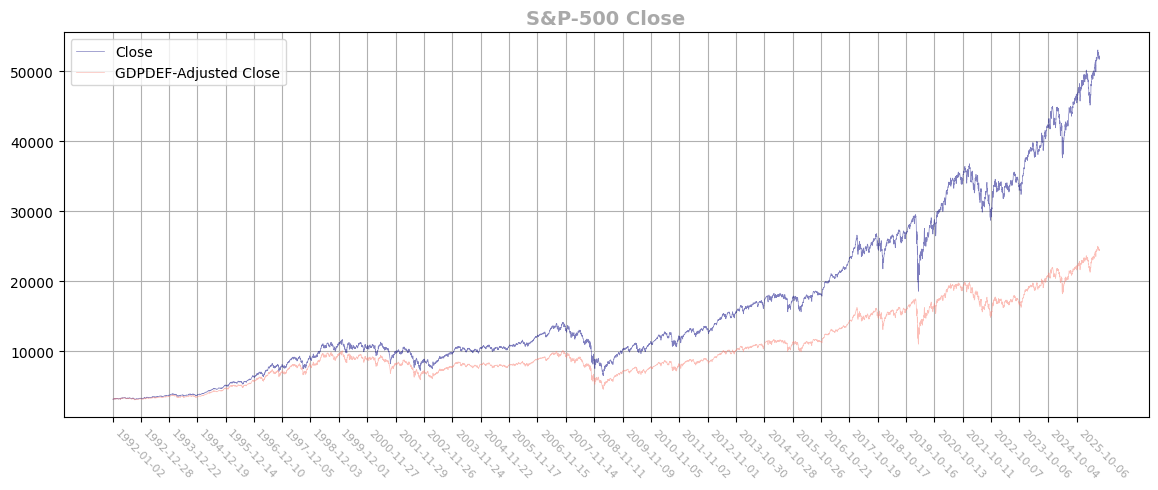

In [44]:
fig = plt.figure(figsize=(14., 5.0))
ax = fig.gca()

day = gdpdef_adj_dji_df["Day"].to_numpy()
close = gdpdef_adj_dji_df["Close"].to_numpy()
gdp_def = gdpdef_adj_dji_df["GDPDEF"].to_numpy()
gdp_def = gdp_def / gdp_def[0]
dates = gdpdef_adj_dji_df["Date"].to_numpy()

ax.set_title("S&P-500 Close", fontsize=14, fontweight="bold", color="darkgrey")
# ax.plot(day, gdp_def, lw=0.5, color="navy", alpha=0.5, label="gdp_def")
ax.plot(day, close, lw=0.5, color="navy", alpha=0.5, label="Close")
ax.plot(day, close / gdp_def, lw=0.5, color="salmon", alpha=0.5, label="GDPDEF-Adjusted Close")
ax.legend(loc="upper left")
ax.set_xticks(day[::250])
ax.set_xticklabels(dates[::250], fontsize=8, color="darkgrey", rotation=-45, ha="left", va="top")
ax.grid()
ax.set_axisbelow(True)

plt.show()


## Fit to Historical Close Prices:

In [45]:
day = gdpdef_adj_sp500_df["Day"].to_numpy()
close = gdpdef_adj_sp500_df["Close"].to_numpy()
gdp_def = gdpdef_adj_sp500_df["GDPDEF"].to_numpy()
gdp_def = gdp_def / gdp_def[0]
gdpdef_adj_close = close / gdp_def
dates = gdpdef_adj_sp500_df["Date"].to_numpy()
log_close = np.log(close)
log_gdpdef_adj_close = np.log(gdpdef_adj_close)

strt_date = "2015-01-01"
end_date =  "2025-01-01"
target_date = sp500_df['Date'].iloc[-1]

strt_day_idx = sp500_df.index[sp500_df["DATETIME"] >= strt_date][0]
end_day_idx = sp500_df.index[sp500_df["DATETIME"] > end_date][0]
target_day_idx = sp500_df.index[sp500_df["DATETIME"] >= target_date][0]

print("Dates:")
print(f"\tStart Date:  {sp500_df['Date'].iloc[strt_day_idx]}")
print(f"\tEnd Date:    {sp500_df['Date'].iloc[end_day_idx]}")
print(f"\tTarget Date: {sp500_df['Date'].iloc[target_day_idx]}")

Dates:
	Start Date:  2015-01-02
	End Date:    2025-01-02
	Target Date: 2026-07-24


In [46]:
fit_results = linregress(day[strt_day_idx:end_day_idx], log_close[strt_day_idx:end_day_idx])
fit_points = fit_results[0] * day[strt_day_idx:target_day_idx] + fit_results[1]

adj_fit_results = linregress(day[strt_day_idx:end_day_idx], log_gdpdef_adj_close[strt_day_idx:end_day_idx])
adj_fit_points = adj_fit_results[0] * day[strt_day_idx:target_day_idx] + adj_fit_results[1]

print("\tSlope:       ", np.around(fit_results[0], 7))
print("\tIntercept:   ", np.around(fit_results[1], 7))
# print("\tExp Slope: ", np.around(np.exp(fit_results[0]), 7))
print("\tEst. Annual: ", np.around(np.power(1.0 + fit_results[0], 365) - 1.0, 7))
max_log_delta = np.max(log_close[strt_day_idx:target_day_idx] - fit_points)
print("Ratio of Expected to Current: ", np.around(np.exp(fit_points[-1] - log_close[target_day_idx]), 7))
print("Max Deviation:                ", np.around(np.exp(max_log_delta), 7))

print("\nProjected Price:              ", np.around(np.exp(fit_points[-1]), 3))

	Slope:        0.0002937
	Intercept:    8.7717172
	Est. Annual:  0.1131399
Ratio of Expected to Current:  0.8693436
Max Deviation:                 1.2139546

Projected Price:               6443.558


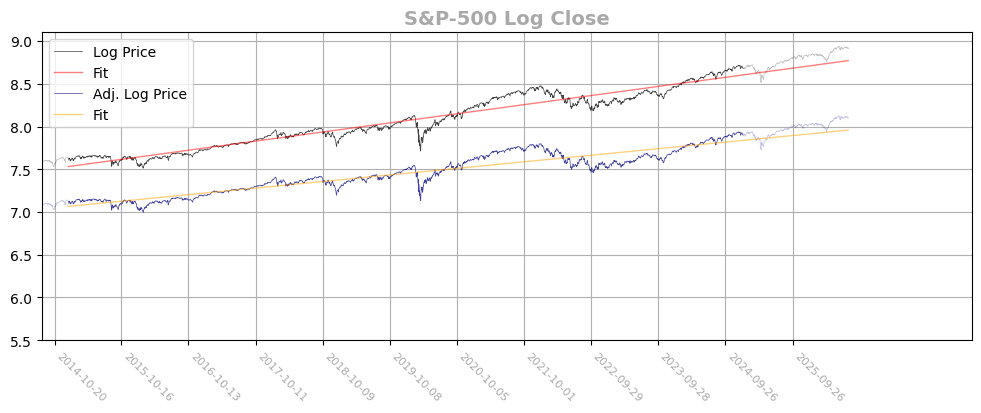

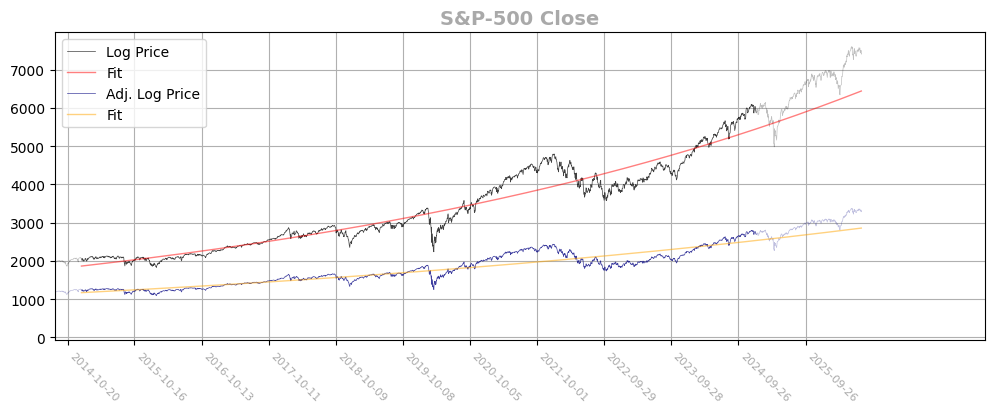

In [47]:
## Log Close Plot
fig = plt.figure(figsize=(12., 4.0))
ax = fig.gca()
#
ax.set_title("S&P-500 Log Close", fontsize=14, fontweight="bold", color="darkgrey")
ax.plot(day[strt_day_idx:end_day_idx], log_close[strt_day_idx:end_day_idx], 
        lw=0.5, color="black", alpha=0.75, label="Log Price")
ax.plot(day[:strt_day_idx], log_close[:strt_day_idx], lw=0.5, color="black", alpha=0.25, label=None)
ax.plot(day[end_day_idx:], log_close[end_day_idx:], lw=0.5, color="black", alpha=0.25, label=None)
ax.plot(day[strt_day_idx:target_day_idx], fit_points, lw=1.0, color="red", alpha=0.5, label="Fit")
#
ax.plot(day[strt_day_idx:end_day_idx], log_gdpdef_adj_close[strt_day_idx:end_day_idx], 
        lw=0.5, color="navy", alpha=0.75, label="Adj. Log Price")
ax.plot(day[:strt_day_idx], log_gdpdef_adj_close[:strt_day_idx], lw=0.5, color="navy", alpha=0.25, label=None)
ax.plot(day[end_day_idx:], log_gdpdef_adj_close[end_day_idx:], lw=0.5, color="navy", alpha=0.25, label=None)
ax.plot(day[strt_day_idx:target_day_idx], adj_fit_points, lw=1.0, color="orange", alpha=0.5, label="Fit")
#
ax.legend(loc="upper left")
ax.set_xticks(day[::250])
ax.set_xticklabels(dates[::250], fontsize=8, color="darkgrey", rotation=-45, ha="left", va="top")
ax.grid()
ax.set_axisbelow(True)
ax.set_xlim(day[strt_day_idx-100],)
#
plt.show()


## Close Plot
fig = plt.figure(figsize=(12., 4.0))
ax = fig.gca()
#
ax.set_title("S&P-500 Close", fontsize=14, fontweight="bold", color="darkgrey")
ax.plot(day[strt_day_idx:end_day_idx], close[strt_day_idx:end_day_idx], 
        lw=0.5, color="black", alpha=0.75, label="Log Price")
ax.plot(day[:strt_day_idx], close[:strt_day_idx], lw=0.5, color="black", alpha=0.25, label=None)
ax.plot(day[end_day_idx:], close[end_day_idx:], lw=0.5, color="black", alpha=0.25, label=None)
ax.plot(day[strt_day_idx:target_day_idx], np.exp(fit_points), lw=1.0, color="red", alpha=0.5, label="Fit")
#
ax.plot(day[strt_day_idx:end_day_idx], gdpdef_adj_close[strt_day_idx:end_day_idx], 
        lw=0.5, color="navy", alpha=0.75, label="Adj. Log Price")
ax.plot(day[:strt_day_idx], gdpdef_adj_close[:strt_day_idx], lw=0.5, color="navy", alpha=0.25, label=None)
ax.plot(day[end_day_idx:], gdpdef_adj_close[end_day_idx:], lw=0.5, color="navy", alpha=0.25, label=None)
ax.plot(day[strt_day_idx:target_day_idx], np.exp(adj_fit_points), lw=1.0, color="orange", alpha=0.5, label="Fit")
#
ax.legend(loc="upper left")
ax.set_xticks(day[::250])
ax.set_xticklabels(dates[::250], fontsize=8, color="darkgrey", rotation=-45, ha="left", va="top")
ax.grid()
ax.set_axisbelow(True)
ax.set_xlim(day[strt_day_idx-100],)
#
plt.show()

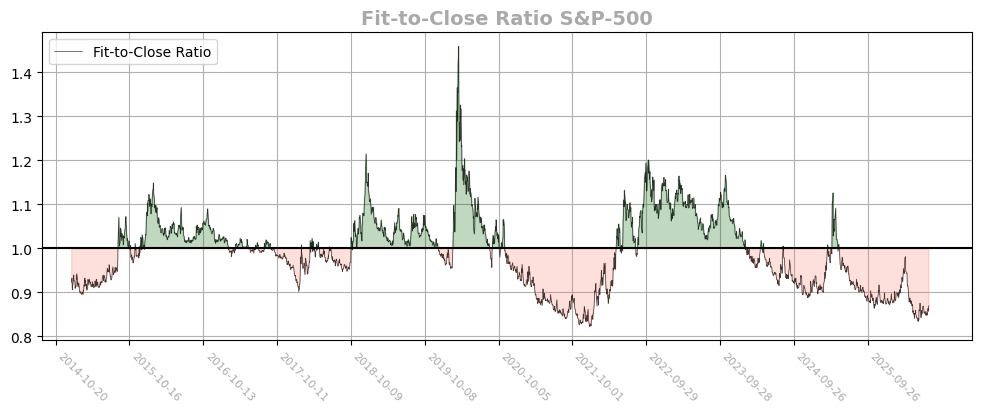

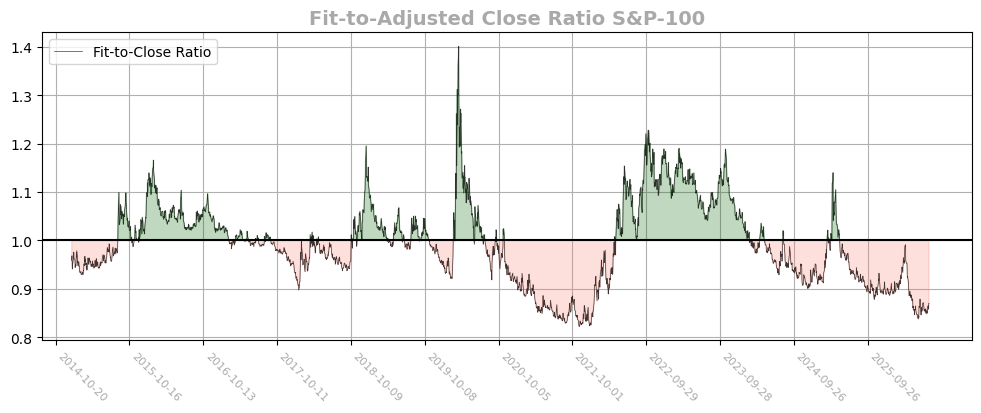

In [48]:
## Relative Close Plot
fig = plt.figure(figsize=(12., 4.0))
ax = fig.gca()
#
ax.set_title("Fit-to-Close Ratio S&P-500", fontsize=14, fontweight="bold", color="darkgrey")
x = day[strt_day_idx + 1:]
y = np.exp(fit_points) / close[strt_day_idx + 1:]
ax.plot(x, y, lw=0.5, color="black", alpha=0.75, label="Fit-to-Close Ratio")
ax.fill_between(x, 1.0, y, where=(y > 1.0), color="darkgreen", alpha=0.25)
ax.fill_between(x, 1.0, y, where=(y < 1.0), color="salmon", alpha=0.25)
ax.axhline(y = 1.0, color="black", linestyle="-", lw=1.5)
ax.legend(loc="upper left")
ax.set_xticks(day[::250])
ax.set_xticklabels(dates[::250], fontsize=8, color="darkgrey", rotation=-45, ha="left", va="top")
ax.grid()
ax.set_axisbelow(True)
ax.set_xlim(day[strt_day_idx-100],)
#
plt.show()


## GDP-Adjusted Relative Close Plot
fig = plt.figure(figsize=(12., 4.0))
ax = fig.gca()
#
ax.set_title("Fit-to-Adjusted Close Ratio S&P-100", fontsize=14, fontweight="bold", color="darkgrey")
x = day[strt_day_idx + 1:]
y = np.exp(adj_fit_points) / gdpdef_adj_close[strt_day_idx + 1:]
ax.plot(x, y, lw=0.5, color="black", alpha=0.75, label="Fit-to-Close Ratio")
ax.fill_between(x, 1.0, y, where=(y > 1.0), color="darkgreen", alpha=0.25)
ax.fill_between(x, 1.0, y, where=(y < 1.0), color="salmon", alpha=0.25)
ax.axhline(y = 1.0, color="black", linestyle="-", lw=1.5)
ax.legend(loc="upper left")
ax.set_xticks(day[::250])
ax.set_xticklabels(dates[::250], fontsize=8, color="darkgrey", rotation=-45, ha="left", va="top")
ax.grid()
ax.set_axisbelow(True)
ax.set_xlim(day[strt_day_idx-100],)
#
plt.show()

## Simple Averaging of Log Returns:

In [49]:
# close = sp500_df["Close"].to_numpy()
# day = sp500_df["Day"].to_numpy()[:-1]
# dates = sp500_df["Date"].to_numpy()[:-1]
# log_return = np.log(close[1:] / close[:-1])

# print("Log Return Mean & STD :")
# log_returns_in_range = log_return[strt_day_idx:end_day_idx]
# est_err = log_returns_in_range.std() / np.sqrt(log_returns_in_range.size)
# print(" - Mean: ", np.around(log_returns_in_range.mean(), 7), "±", np.around(est_err, 7))
# print(" - STD:  ", np.around(log_returns_in_range.std(), 7))


# fig = plt.figure(figsize=(12., 4.0))
# ax = fig.gca()
# #
# ax.set_title("Log Return", fontsize=14, fontweight="bold", color="darkgrey")
# ax.plot(day[:strt_day_idx], log_return[:strt_day_idx], lw=0.5, color="darkgrey", alpha=0.5)
# ax.plot(day[strt_day_idx:end_day_idx], log_return[strt_day_idx:end_day_idx], 
#         lw=0.5, color="steelblue", alpha=0.5)
# ax.plot(day[end_day_idx:], log_return[end_day_idx:], lw=0.5, color="darkgrey", alpha=0.5)
# ax.set_xticks(day[::250])
# ax.set_xticklabels(dates[::250], fontsize=8, color="darkgrey", rotation=-45, ha="left", va="top")
# ax.grid()
# ax.set_axisbelow(True)
# #
# plt.show()

## Cummulative Gain During Period:

In [50]:
# day = sp500_df["Day"].to_numpy()
# low = sp500_df["Low"].to_numpy()
# high = sp500_df["High"].to_numpy()
# close = sp500_df["Close"].to_numpy()
# dates = sp500_df["Date"].to_numpy()

# cumm_strt_date = "2018-01-01"
# cumm_end_date =  "2023-01-01"
# cumm_target_date = sp500_df['Date'].iloc[-1]

# cumm_strt_day_idx = sp500_df.index[sp500_df["DATETIME"] >= cumm_strt_date][0]
# cumm_end_day_idx = sp500_df.index[sp500_df["DATETIME"] > cumm_end_date][0]
# cumm_target_day_idx = sp500_df.index[sp500_df["DATETIME"] >= cumm_target_date][0]

# print("Dates:")
# print(f"\tStart Date:  {sp500_df['Date'].iloc[cumm_strt_day_idx]}")
# print(f"\tEnd Date:    {sp500_df['Date'].iloc[cumm_end_day_idx]}")
# print(f"\tTarget Date: {sp500_df['Date'].iloc[cumm_target_day_idx]}")

In [51]:
# # Compute number of shares if purchased daily with a fix amount:
# low_num_shares = np.sum(1.0 / high[cumm_strt_day_idx:cumm_end_day_idx])
# high_num_shares = np.sum(1.0 / low[cumm_strt_day_idx:cumm_end_day_idx])
# close_num_shares = np.sum(1.0 / close[cumm_strt_day_idx:cumm_end_day_idx])

# num_days = cumm_end_day_idx - cumm_strt_day_idx
# min_period_gain = low[cumm_target_day_idx] * low_num_shares / num_days
# max_period_gain = high[cumm_target_day_idx] * high_num_shares / num_days
# close_period_gain = close[cumm_target_day_idx] * close_num_shares / num_days

# print(f"\tMin Gain at Target:   {np.around(min_period_gain, 3)}")
# print(f"\tMax Gain at Target:   {np.around(max_period_gain, 3)}")
# print(f"\tClose Gain at Target: {np.around(close_period_gain, 3)}")

# annual_inflation_rate = 3.5
# inflation = np.power(1.0 + 0.01 * annual_inflation_rate, num_days / 365)
# print(f"\tInflation (at {annual_inflation_rate}% annual rate): {np.round(inflation, 2)}")